In [0]:
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import *
import datetime

np.random.seed(42)
n = 2000

distritos = ["Miraflores", "San Isidro", "SJL", "Comas", "Villa El Salvador",
             "Los Olivos", "Surco", "Ate", "Callao", "Independencia"]
tipos     = ["persona_a_persona", "persona_a_comercio", "retiro_bcp", "recarga"]
estados   = ["completada", "completada", "completada", "rechazada", "pendiente"]

base_date = datetime.datetime(2025, 1, 1)
fechas_lista = [(base_date + datetime.timedelta(hours=i)).strftime("%Y-%m-%d") for i in range(n)]

data = {
    "id_transaccion": [f"YP{i:07d}" for i in range(1, n+1)],
    "fecha":          fechas_lista,
    "hora":           [f"{h:02d}:{m:02d}" for h, m in zip(np.random.randint(0,24,n), np.random.randint(0,60,n))],
    "monto_soles":    np.round(np.random.exponential(45, n), 2).tolist(),
    "tipo":           np.random.choice(tipos, n).tolist(),
    "distrito_origen":np.random.choice(distritos, n).tolist(),
    "estado":         np.random.choice(estados, n, p=[0.75, 0.1, 0.05, 0.07, 0.03]).tolist(),
    "id_usuario":     [f"USR{np.random.randint(1000,9999)}" for _ in range(n)],
    "es_comercio":    [bool(x) for x in np.random.choice([True, False], n, p=[0.4, 0.6]).tolist()]
}

df_pandas = pd.DataFrame(data)
df_bronze = spark.createDataFrame(df_pandas)

# SOLUCIÓN SERVERLESS: En vez de escribir un archivo parquet en un disco bloqueado,
# lo registramos directamente como una vista temporal en memoria.
df_bronze.createOrReplaceTempView("transacciones_bronze")

print(f"✅ Bronze layer: {df_bronze.count()} transacciones guardadas en memoria virtual")
df_bronze.show(5)

✅ Bronze layer: 2000 transacciones guardadas en memoria virtual
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|id_transaccion|     fecha| hora|monto_soles|              tipo|distrito_origen|    estado|id_usuario|es_comercio|
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|     YP0000001|2025-01-01|06:25|      35.47| persona_a_persona|          Surco|completada|   USR9055|      false|
|     YP0000002|2025-01-01|19:07|       4.16|persona_a_comercio|          Surco|completada|   USR4216|       true|
|     YP0000003|2025-01-01|14:35|      42.01|        retiro_bcp|     San Isidro|completada|   USR6688|      false|
|     YP0000004|2025-01-01|10:47|        7.4|        retiro_bcp|     Los Olivos|completada|   USR5364|      false|
|     YP0000005|2025-01-01|07:29|       1.41|           recarga|     San Isidro|completada|   USR7042|      false|
+--------------+

In [0]:
# ============================================================
# CELDA 2: Silver — limpiar y transformar
# ============================================================
import pyspark.sql.functions as F

# 1. Leemos directamente de la memoria virtual (Capa Bronze)
df_bronze = spark.table("transacciones_bronze")

# 2. Filtramos y enriquecemos los datos aplicando las pistas del profesor
df_silver = df_bronze \
    .filter(df_bronze.estado == "completada") \
    .filter(df_bronze.monto_soles > 0) \
    .withColumn("categoria_monto",
        F.when(F.col("monto_soles") < 20, "micro") \
         .when(F.col("monto_soles") < 100, "medio") \
         .otherwise("alto")) \
    .withColumn("es_hora_pico",
        F.when(F.col("hora").between("12:00", "14:00"), True) \
         .when(F.col("hora").between("18:00", "22:00"), True) \
         .otherwise(False)) \
    .withColumn("comision_yape",
        F.when(F.col("tipo") == "persona_a_comercio",
               F.round(F.col("monto_soles") * 0.015, 2)) \
         .otherwise(0.0))

# 3. Guardamos en la memoria virtual para que la Capa Gold pueda leerlo
df_silver.createOrReplaceTempView("transacciones_silver")

# 4. Mostramos los resultados en pantalla
print(f"✅ Silver layer: {df_silver.count()} transacciones válidas")
print(f"   Eliminadas: {df_bronze.count() - df_silver.count()} (rechazadas/pendientes/monto cero)")

# Mostramos el conteo por categoría de monto para verificar que funcione
df_silver.groupBy("categoria_monto").count().show()

✅ Silver layer: 1802 transacciones válidas
   Eliminadas: 198 (rechazadas/pendientes/monto cero)
+---------------+-----+
|categoria_monto|count|
+---------------+-----+
|           alto|  202|
|          micro|  634|
|          medio|  966|
+---------------+-----+



In [0]:
# ============================================================
# CELDA 3: Gold — Agregaciones y KPIs de Negocio
# ============================================================
import pyspark.sql.functions as F

# 1. Leemos de la capa Silver en memoria
df_silver = spark.table("transacciones_silver")

print("📊 === REPORTE GENERAL DE NEGOCIO (CAPA GOLD) === 📊\n")

# 2. KPI GLOBAL: Sumamos montos, comisiones y contamos transacciones
# Completamos con: sum, sum y count
kpis_globales = df_silver.select(
    F.round(F.sum("monto_soles"), 2).alias("Monto_Total_Soles"),
    F.round(F.sum("comision_yape"), 2).alias("Total_Comisiones_Ganadas"),
    F.count("id_transaccion").alias("Total_Transacciones_Exitosas")
)
print("1. KPIs Globales de Yape:")
kpis_globales.show()

# 3. RANKING: Agrupamos por distrito y ordenamos de mayor a menor
# Completamos con: distrito_origen, sum y el alias Monto_Total
reporte_distritos = df_silver.groupBy("distrito_origen") \
    .agg(F.round(F.sum("monto_soles"), 2).alias("Monto_Total")) \
    .orderBy(F.col("Monto_Total").desc())

print("2. Top 3 Distritos con mayor movimiento económico:")
reporte_distritos.show(3)

# 4. EFICIENCIA: Promedio de gasto en Hora Pico vs Normal
# Completamos con: es_hora_pico y avg
reporte_horas = df_silver.groupBy("es_hora_pico") \
    .agg(F.round(F.avg("monto_soles"), 2).alias("Monto_Promedio_Por_Transaccion"))

print("3. ¿La gente gasta más en Hora Pico?")
reporte_horas.show()

📊 === REPORTE GENERAL DE NEGOCIO (CAPA GOLD) === 📊

1. KPIs Globales de Yape:
+-----------------+------------------------+----------------------------+
|Monto_Total_Soles|Total_Comisiones_Ganadas|Total_Transacciones_Exitosas|
+-----------------+------------------------+----------------------------+
|         82583.79|                  307.02|                        1802|
+-----------------+------------------------+----------------------------+

2. Top 3 Distritos con mayor movimiento económico:
+---------------+-----------+
|distrito_origen|Monto_Total|
+---------------+-----------+
|          Surco|    9152.14|
|  Independencia|    8968.04|
|         Callao|    8929.61|
+---------------+-----------+
only showing top 3 rows
3. ¿La gente gasta más en Hora Pico?
+------------+------------------------------+
|es_hora_pico|Monto_Promedio_Por_Transaccion|
+------------+------------------------------+
|        true|                         45.38|
|       false|                         45.98|

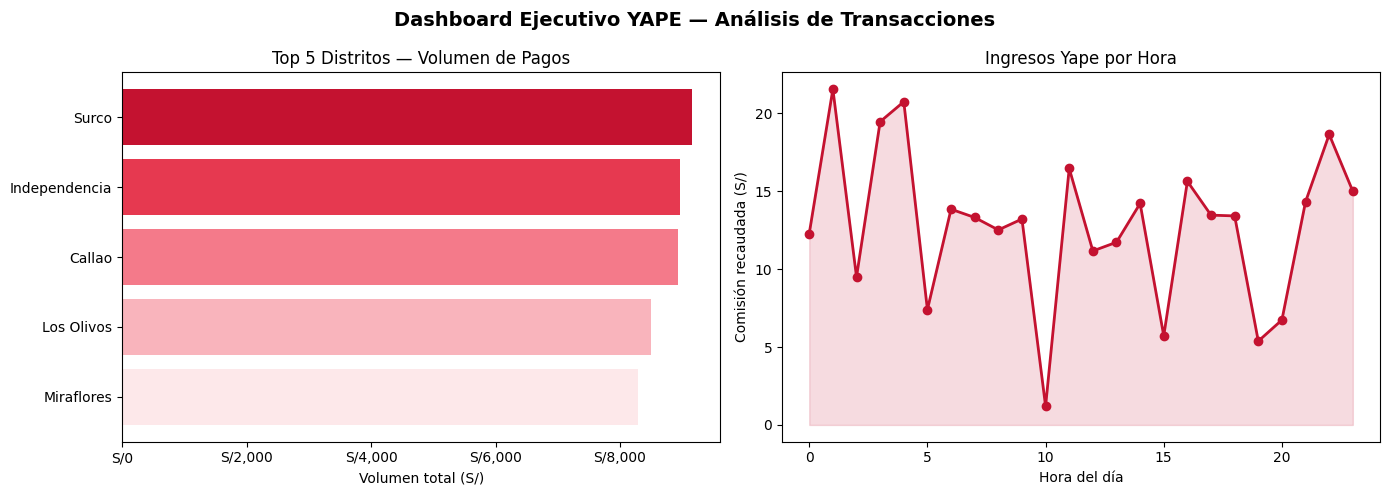

In [0]:
# ============================================================
# CELDA 4: Visualización — Dashboard Ejecutivo Yape (Salida Única)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyspark.sql.functions as F

# 1. Extraemos los datos necesarios directamente de la capa Silver en memoria
df_silver_data = spark.table("transacciones_silver")

# Procesamos los datos para el Gráfico 1 (Top 5 distritos)
gold_distritos = df_silver_data.groupBy("distrito_origen") \
    .agg(F.sum("monto_soles").alias("volumen_total_soles")) \
    .orderBy(F.col("volumen_total_soles").desc()) \
    .limit(5).toPandas()

# Procesamos los datos para el Gráfico 2 (Ingresos Yape por hora)
gold_comisiones = df_silver_data \
    .withColumn("hora_dia", F.substring("hora", 1, 2).cast("int")) \
    .groupBy("hora_dia") \
    .agg(F.sum("comision_yape").alias("ingresos_yape_soles")) \
    .toPandas()

# 2. Construcción del Dashboard (Un solo lienzo con 2 paneles)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dashboard Ejecutivo YAPE — Análisis de Transacciones", fontsize=14, fontweight='bold')

# --- Panel Izquierdo: Top 5 distritos ---
axes[0].barh(gold_distritos["distrito_origen"], gold_distritos["volumen_total_soles"],
             color=["#c41230","#e63950","#f47a8a","#f9b4bc","#fde8ea"])
axes[0].set_xlabel("Volumen total (S/)")
axes[0].set_title("Top 5 Distritos — Volumen de Pagos")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/{x:,.0f}"))
axes[0].invert_yaxis()

# --- Panel Derecho: Ingresos Yape por Hora ---
gold_comisiones_sorted = gold_comisiones.sort_values("hora_dia")
axes[1].plot(gold_comisiones_sorted["hora_dia"], gold_comisiones_sorted["ingresos_yape_soles"],
             marker='o', color='#c41230', linewidth=2)
axes[1].fill_between(gold_comisiones_sorted["hora_dia"], gold_comisiones_sorted["ingresos_yape_soles"],
                     alpha=0.15, color='#c41230')
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Comisión recaudada (S/)")
axes[1].set_title("Ingresos Yape por Hora")

plt.tight_layout()

# 3. Evitamos la duplicación cerrando el dibujo automático antes del display
plt.close(fig) 
display(fig)